# Curriculum Sequential Learning — Per-Rule Test Accuracy

Two subplots:
- **Left**: Model A (learn [1,1] first, then mix [1,1]+[2,3])
- **Right**: Model B (learn [2,3] first, then mix [1,1]+[2,3])

Each subplot has 4 lines (2 seeds x 2 rules):
- seed=17996, rule [1,1]
- seed=17996, rule [2,3]
- seed=18318, rule [1,1]
- seed=18318, rule [2,3]

X-axis: continuous epoch (Stage1 + Stage2 concatenated; Stage2 epochs are shifted by Stage1 max epoch + 1).
Y-axis: per-rule test accuracy.
Vertical dotted line marks the Stage1 -> Stage2 warm-start transition.
Rules not shown during Stage1 are absent (the model has not seen them yet).

In [1]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

LOG_DIR = Path('/data/lly/recursion/recursion_results/curriculum_sequential')

EPOCH_RE = re.compile(
    r'Epoch\s+(\d+)\s+\|\s+Train:\s+Loss=([\d.]+)\s+Acc=([\d.]+%?)\s+\|\s+'
    r'Test:\s+Acc=([\d.]+%?)\s+\|\s+Best=([\d.]+%?)\(@(\d+)\)'
)
RULE_RE = re.compile(r'per-rule acc:\s+(.+)')
STAGE_RE = re.compile(r'--- Stage(\d) output ---')

def parse_curriculum_log(path):
    """Parse a curriculum log into stages.
    Returns dict: {'1': {'epochs': [], 'per_rule': [[...]]},
                    '2': {'epochs': [], 'per_rule': [[...]]}}
    """
    stages = {'1': {'epochs': [], 'per_rule': []},
              '2': {'epochs': [], 'per_rule': []}}
    current_stage = None
    pending_rule = None

    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            m = STAGE_RE.search(line)
            if m:
                current_stage = m.group(1)
                pending_rule = None
                continue
            m = EPOCH_RE.search(line)
            if m and current_stage:
                epoch = int(m.group(1))
                stages[current_stage]['epochs'].append(epoch)
                # placeholder, will be filled by per-rule line that follows
                stages[current_stage]['per_rule'].append(pending_rule if pending_rule is not None else [])
                pending_rule = None
                continue
            m = RULE_RE.search(line)
            if m and current_stage:
                accs = [float(x) for x in m.group(1).split()]
                # fill the most recent epoch's placeholder
                if stages[current_stage]['per_rule']:
                    stages[current_stage]['per_rule'][-1] = accs
                continue
    return stages

def build_per_rule_curve(stages, stage1_rule_idx, stage2_rule_idx):
    """Build a continuous per-rule acc curve for one rule.
    stage1_rule_idx: index of this rule in Stage1 per_rule (None if rule not in stage1)
    stage2_rule_idx: index of this rule in Stage2 per_rule (None if rule not in stage2)
    Returns (epochs, accs, stage1_last_epoch)
    """
    epochs_out, accs_out = [], []
    # Stage1
    s1 = stages['1']
    s1_last_epoch = -1
    for i, ep in enumerate(s1['epochs']):
        s1_last_epoch = max(s1_last_epoch, ep)
        per_rule = s1['per_rule'][i] if i < len(s1['per_rule']) else []
        if stage1_rule_idx is not None and stage1_rule_idx < len(per_rule):
            epochs_out.append(ep)
            accs_out.append(per_rule[stage1_rule_idx])
        else:
            # rule not in stage1, skip (NaN gap)
            pass
    # Stage2: shift epochs by s1_last_epoch + 1
    s2 = stages['2']
    offset = s1_last_epoch + 1
    for i, ep in enumerate(s2['epochs']):
        per_rule = s2['per_rule'][i] if i < len(s2['per_rule']) else []
        if stage2_rule_idx is not None and stage2_rule_idx < len(per_rule):
            epochs_out.append(ep + offset)
            accs_out.append(per_rule[stage2_rule_idx])
    return np.array(epochs_out), np.array(accs_out), s1_last_epoch

print('Helper functions defined.')

Helper functions defined.


In [2]:
# Model A: stage1 rule = [1,1]; stage2 rules = [[1,1], [2,3]]
#   rule [1,1] -> stage1 idx 0, stage2 idx 0
#   rule [2,3] -> stage1: None, stage2 idx 1
modelA_logs = {
    17996: LOG_DIR / 'modelA.out',
    18318: LOG_DIR / 'modelA_seed18318_gpu4.out',
}

# Model B: stage1 rule = [2,3]; stage2 rules = [[1,1], [2,3]]
#   rule [1,1] -> stage1: None, stage2 idx 0
#   rule [2,3] -> stage1 idx 0, stage2 idx 1
modelB_logs = {
    17996: LOG_DIR / 'modelB.out',
    18318: LOG_DIR / 'modelB_seed18318_gpu5.out',
}

modelA_stages = {seed: parse_curriculum_log(p) for seed, p in modelA_logs.items()}
modelB_stages = {seed: parse_curriculum_log(p) for seed, p in modelB_logs.items()}

# Sanity: print stage lengths
for name, stages_by_seed in [('Model A', modelA_stages), ('Model B', modelB_stages)]:
    for seed, st in stages_by_seed.items():
        print(f'{name} seed={seed}: stage1 epochs={len(st["1"]["epochs"])}, stage2 epochs={len(st["2"]["epochs"])}')

Model A seed=17996: stage1 epochs=26, stage2 epochs=28
Model A seed=18318: stage1 epochs=27, stage2 epochs=49
Model B seed=17996: stage1 epochs=56, stage2 epochs=24
Model B seed=18318: stage1 epochs=96, stage2 epochs=51


In [3]:
# Build curves for each (model, seed, rule)
# Model A: rule [1,1] = (s1_idx=0, s2_idx=0); rule [2,3] = (s1_idx=None, s2_idx=1)
modelA_curves = {}
for seed, st in modelA_stages.items():
    ep_11, acc_11, _ = build_per_rule_curve(st, stage1_rule_idx=0, stage2_rule_idx=0)
    ep_23, acc_23, s1_last = build_per_rule_curve(st, stage1_rule_idx=None, stage2_rule_idx=1)
    # stage1 last epoch (for transition marker) - get from the [1,1] curve
    modelA_curves[seed] = {
        'rule_11': (ep_11, acc_11),
        'rule_23': (ep_23, acc_23),
        'stage1_last_epoch': max(st['1']['epochs']) if st['1']['epochs'] else 0,
    }

# Model B: rule [1,1] = (s1_idx=None, s2_idx=0); rule [2,3] = (s1_idx=0, s2_idx=1)
modelB_curves = {}
for seed, st in modelB_stages.items():
    ep_11, acc_11, _ = build_per_rule_curve(st, stage1_rule_idx=None, stage2_rule_idx=0)
    ep_23, acc_23, s1_last = build_per_rule_curve(st, stage1_rule_idx=0, stage2_rule_idx=1)
    modelB_curves[seed] = {
        'rule_11': (ep_11, acc_11),
        'rule_23': (ep_23, acc_23),
        'stage1_last_epoch': max(st['1']['epochs']) if st['1']['epochs'] else 0,
    }

print('Curves built.')

Curves built.


Figure saved to /data/lly/recursion/figures/curriculum_masked2mixture_per_rule_acc.png


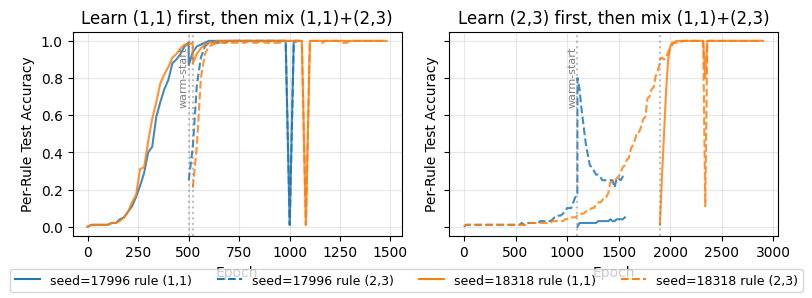

In [4]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

seed_colors = {17996: 'C0', 18318: 'C1'}
rule_styles = {'rule_11': '-', 'rule_23': '--'}
rule_labels = {'rule_11': 'rule (1,1)', 'rule_23': 'rule (2,3)'}

def plot_model(ax, curves_by_seed, title):
    for seed in sorted(curves_by_seed.keys()):
        data = curves_by_seed[seed]
        for rule_key in ['rule_11', 'rule_23']:
            eps, accs = data[rule_key]
            if len(eps) == 0:
                continue
            ax.plot(eps, accs,
                    linestyle=rule_styles[rule_key],
                    color=seed_colors[seed],
                    alpha=0.85, linewidth=1.5)
        # Stage transition marker
        s1_last = data['stage1_last_epoch']
        ax.axvline(s1_last + 0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Per-Rule Test Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

plot_model(axes[0], modelA_curves, 'Learn (1,1) first, then mix (1,1)+(2,3)')
plot_model(axes[1], modelB_curves, 'Learn (2,3) first, then mix (1,1)+(2,3)')

# Add a text annotation for the stage1->stage2 transition on the first subplot
for ax, curves in [(axes[0], modelA_curves), (axes[1], modelB_curves)]:
    # take the first seed's stage1_last_epoch as representative
    first_seed = sorted(curves.keys())[0]
    s1_last = curves[first_seed]['stage1_last_epoch']
    ax.text(s1_last + 0.5, 0.97, 'warm-start', rotation=90,
            va='top', ha='right', color='gray', fontsize=8)

# Shared legend: 4 entries = 2 seeds (blue/orange) x 2 rules (solid/dashed)
legend_handles = [
    mlines.Line2D([], [], color=seed_colors[seed], linestyle=rule_styles[rule_key],
                  label=f'seed={seed} {rule_labels[rule_key]}')
    for seed in sorted(seed_colors)
    for rule_key in ['rule_11', 'rule_23']
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9)

plt.tight_layout()
out_path = Path('/data/lly/recursion/figures/curriculum_masked2mixture_per_rule_acc.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Figure saved to {out_path}')
plt.show()